# CSE 25 - Introduction to Artificial Intelligence
## Week 8 Tuesday and Thursday: Reinforcement Learning

**Learning Objectives:**

- Describe the agent-environment interaction and identify its key components: states, actions, and rewards.
- Explain why a constant learning rate (alpha) is necessary for tracking changing trends compared to a standard average (1/t).
- Deconstruct the Q-learning update rule into its constituent parts: Old Guess, Reward, and Future Potential.
- Implement the Q-learning update rule.
- Calculate discounted future rewards using the discount factor (gamma).
- Apply the epsilon-greedy strategy to balance the exploration-exploitation dilemma.
- Perform policy extraction to derive optimal actions from a completed Q-table.
- Train an agent to play (a version of) Nim using Q-learning.
- Analyze the learning curve and performance of a trained agent.

Instructions

Use your copy of this notebook on Datahub and complete it during class. Work through the cells below **in order**. You may discuss with your neighbors, but make sure you understand each step yourself.

SUBMISSION:
When finished, download the notebook to have a local copy for your records. Choose two cells where you wrote code or answers and take screenshots of them to upload to Gradescope under `In-Class – Week 8 Tuesday` and `In-Class – Week 8 Thursday` to receive credit. 

**Today’s focus:**  
How can an agent learn to make good decisions through trial and error, using rewards and punishments?

### Reinforcement Learning

Reinforcement Learning is about learning by *trial and error*.

Imagine learning to play a new game:

- You try something.
- You see what happens.
- If it works, you're more likely to do it again.
- If it doesn't, you try something different.

That is the core idea of reinforcement learning.

Instead of being told the correct answer (like in supervised learning),
an agent must *interact* with its environment and learn from the outcomes
of its own actions.

The goal is simple: **Learn to make decisions that lead to good outcomes over time.**

#### Agent and Environment

In reinforcement learning, we describe the world using two parts:

- The **agent**: the learner and decision-maker.
- The **environment**: everything the agent interacts with.

NOTE: Agents are actors of any kind. They can be embodied in the physical world or embedded in a virtual environment.

<img src="images/agent-env-mdp.png" width="500">

#### The Agent–Environment Interaction

Reinforcement learning is built around repeated interaction between the **agent** and the **environment**.

At each step:

1. The agent observes the current **state** $s$ of the environment.
2. The agent chooses an **action** $a$ from allowed actions.
3. The environment 
   - responds with a **reward** $r$
   - moves to the **next state** $s'$


#### Key Components

- **State ($s$)**: A representation of the environment.
- **Action ($a$)**: A choice the agent can make in that state to affect the environment.
- **Reward ($r$)**: A numerical signal from the environment indicating how good (or bad) the outcome was.
- **Next state ($s'$)**: The updated representation of the environment that results after taking action $a$ in state $s$.

### Demo: Nim

Nim is a turn-based game where players remove objects from (some number of) pile(s). Depending on the version, the player who takes the last object either wins (standard Nim) or loses (misère Nim).

#### The Game Rules (Our Version)
- We start with one pile with **6 objects**.
- On each turn, a player may remove **1 or 2 objects**.
- The player who takes the last object **loses**(misère Nim).

Q: Does Player 1 have a winning strategy? Does player 2 have a winning strategy?

`YOUR ANSWER HERE`

#### Modeling this version of Nim: States, Actions and Rewards

**States and actions**
Each *state* is the number of objects remaining in the pile. The set of states is $\{1,2,3,4,5,6\}$.

Q: What is the set of actions for the agent in each state?

`YOUR ANSWER HERE`


**Reward ($r$)**:
  - $+1$ for a win,
  - $-1$ for a loss,
  - $0$ at all intermediate steps.

### "Matchbox Learning"

Can we program an AI agent to learn a good strategy, without explicitly reasoning out what it should be?

Donald Michie, in 1961, described how to physically train a game-plying system by recording results of successive games and using reinforcement principles. He worked on Tic-Tac-Toe (in Britain, "Noughts and Crosses") and used matchboxes to create **MENACE** (*Machine Educable Noughts And Crosses Engine*)

- Each matchbox represented a board state.
- Each bead color represented a legal move from that state.
- After a win, several beads for the chosen moves were added (strong reward).
- After a loss, beads for the chosen moves were removed (punishment).
- After a draw, a small reward was given (fewer beads added than for a win).

Over time, the probability of selecting a move became proportional to the number of beads for that move, effectively learning a winning strategy.

**Donald Michie Paper:** [Experiments on the Mechanization of Game-Learning](https://people.csail.mit.edu/brooks/idocs/matchbox.pdf)
**A longer description:** Nim activity with cups and paper [https://www.i-am.ai/build-your-own-ai.html](https://www.i-am.ai/build-your-own-ai.html), including link to video of people actually playing Tic-Tac-Toe with matchboxes [(Modern demonstration of MENACE)](https://youtu.be/R9c-_neaxeU?si=WMZ-CxfG6mCqz6aX).

### "Matchbox Learning" for Nim

Lay out 6 cups, numbered $6, 5, 4, 3, 2, 1$ (one for each possible state)

In cups $6$ through $2$, put two slips "1" (remove 1 object), "2" (remove 2 objects). In cup $1$ put one slip "1".

To train the agent: play consecutive games, where in each game,
- The agent plays first.
- To play for the agent, the human helping the agent looks at the cup corresponding to the current state of the game (the number of objects in the pile) and randomly draws one of the slips in the cup. The slip that is drawn is left on the table next to the cup.
The agent then performs the action.
- The opponent takes their turn, and then the agent, back and forth until the game ends.
- After the game ends:
    - If the agent wins, return all the drawn slips to their cups.
    - If the agent loses, discard the slip corresponding to the agent's last action and put the rest of the slips back into their cups to start the next training game. However, if the slip corresponding to the agent's last action was the only slip in that cup, put it back and discard the piece of paper from the previous action (or the one before that, etc. so that cups always have at least one piece of paper).

After playing enough times, each cup may have fewer pieces of paper, converging towards the winning strategy.

Q: How many games did we need to play to fully train the cups for Nim?

`YOUR ANSWER HERE`

Q: Will every training process for this game take the same number of games?

`YOUR ANSWER HERE`

Q: Will every training process for this game lead to the same strategy?

`YOUR ANSWER HERE`

We'll simulate the game in code to illustrate key concepts in reinforcement learning.

In [58]:
# Some helper functions for this variant of the NIM Game 

def get_legal_actions(state):
    '''Returns a list of legal actions based on the current state'''
    # If there are 2 or more objects, you can take either 1 or 2. 
    # If there's only 1 object left, you can only take 1.
    return [1, 2] if state >= 2 else [1]

def apply_action(state, action):
    '''Returns the next state after applying the action to the state'''
    # We assume the action is legal
    return state - action


Q: What does `get_legal_actions(1)` return?

`YOUR ANSWER HERE`

Q: What does `apply_action(3,2)` return?

`YOUR ANSWER HERE`

In [59]:
# Simulating a full game

import random

def sample_game_sequence(
    start_state=6, #number of objects at the start of the game
    policy = None, #dict policy maps states to actions; None means random agent
    agent_first=True,
    seed=None, #random seed for reproducibility; default to None
    print_trace=True #print trace of game sequence; default to True
):
    '''
    Simulate one game of misère Nim (the player who takes the last object loses) and print each move and the final outcome (if printing trace).
    Returns winner.
    '''

    # Initialization
    if seed is not None:
        random.seed(seed)

    state = start_state
    if agent_first:
        player = "Agent"
    else:
        player = "Opponent"
    history = []

    if print_trace: print(f"Game starts with {start_state} object(s).")

    # Take turns
    while state > 0:
        legal = get_legal_actions(state)

        if player == "Agent":
            # Choose action based on policy, or random
            if policy is not None:
                # Follow the provided policy (fall back to random if state not in policy)
                action = policy.get(state, random.choice(legal))
            else :
                # No guidance: pick randomly
                action = random.choice(legal)
        else:
            # Opponent plays randomly
            action = random.choice(legal)

        state_before = state
        state = apply_action(state, action)
        history.append((player, state_before, action, state))

        if print_trace: print(f"  {player} took {action} object(s). {state} remaining.")

        if state == 0:
            # The player who takes the last object LOSES (misère Nim)
            loser = player
            if player == "Agent":
                winner = "Opponent" 
            else:
                winner = "Agent"
            if print_trace: print(f"{loser} took the last object and LOSES. {winner} WINS!")
            return winner

        # Switch player
        player = "Opponent" if player == "Agent" else "Agent"

    # Should not be reached
    return None

In [60]:
sample_game_sequence(6, policy= None, agent_first=True, seed=5)

Game starts with 6 object(s).
  Agent took 2 object(s). 4 remaining.
  Opponent took 2 object(s). 2 remaining.
  Agent took 1 object(s). 1 remaining.
  Opponent took 1 object(s). 0 remaining.
Opponent took the last object and LOSES. Agent WINS!


'Agent'

Q: Find a random seed where the Agent wins in the game simulation above.

`YOUR ANSWER`

Q: Find a random seed where the Opponent wins in the game simulation above.

`YOUR ANSWER`

#### Policy

A **policy** $\pi$ is a function that maps the state space $S$ to the action space $A$. It may be deterministic or stochastic.

#### Optimization Objective
**The goal** of reinforcement learning is to *learn a policy* that maximizes **total expected reward over time**.

**How Do We Actually Learn a Policy?**

In the Nim activity, we improved the policy by removing losing actions. The policy the agent converged to was given by the remaining slip in each cup.

In general, we need something that will capture what we know about how good each position is at maximizing our reward. There are many reinforcement learning algorithms. In this course, we will study one such algorithm called **Q-learning.**

### Tabular Q-Learning 

In Q-learning, instead of slips, we store Q-values for state-action pairs, denoted as $Q(s, a)$ in a table. This value represents the **total expected reward** for taking action $a$ in state $s$ and then continuing to make the **best possible decisions** until the task is complete.

It essentially converts a short-term move into a long-term *quality* score, where higher values indicate a more successful path to the goal.

| State $s$| Take 1 | Take 2 |
|---|---|---|
| 1 | $Q(1,1)$ | $Q(1,2)$ |
| 2 | $Q(2,1)$ | $Q(2,2)$ |
| 3 | $Q(3,1)$ | $Q(3,2)$ |
| 4 | $Q(4,1)$ | $Q(4,2)$ |
| 5 | $Q(5,1)$ | $Q(5,2)$ |
| 6 | $Q(6,1)$ | $Q(6,2)$ |

If we have a completed Q-table, we can **extract a policy** from it. The optimal policy chooses the action that has the highest Q-value for each state.

$$
\pi(s) = \argmax_{a} Q(s,a)
$$

In [61]:
# We can represent the Q-table as a dictionary with tuple keys: (state, action)
# and values being the Q-value for a given state and action pair.
# States: 1, 2, 3, 4, 5, 6 (Playable states), Actions: 1 or 2

def display_q_table(Q):
    # We only care about states where a move is possible (1-6)
    states = sorted({state for state, _ in Q if state > 0})

    print(f"{'State':>5} {'Take 1':>10} {'Take 2':>10}")
    print("-" * 27)

    for state in states:
        q_take_1 = Q.get((state, 1), float("nan"))
        q_take_2 = Q.get((state, 2), float("nan"))
        print(f"{state:>5} {q_take_1:>10.3f} {q_take_2:>10.3f}")
    print("\n")

def optimal_policy_from_Q_table(Q, print_trace=True):
    ''' For each state, choose the action that maximizes the Q-value'''
    optimal_policy = {}
    for state in range(1,7):
        legal = get_legal_actions(state)  # only consider legal actions
        # Check there the set of legal actions is nonempty
        if legal:
            default_action = legal[0]
            best_q_val = Q.get((state,default_action), float('-inf'))
            tied_actions = [default_action]   # keep track of 'best' legal actions
            # Started with legal[0] as current best
            for action in legal[1:]:
                q_val = Q.get((state, action), float('-inf'))
                if (q_val > best_q_val):
                    best_q_val = q_val
                    tied_actions = [action]
                elif (q_val == best_q_val):
                    tied_actions.append(action)
                    
            # Tie breaker:
            # options include max(tied_actions) or random.choice(tied_actions)
            best_action = min(tied_actions)
            optimal_policy[state] = best_action

    print("Optimal Policy (state: best action):")
    for state, action in optimal_policy.items():
        print(f"State {state}: Action {action}")
    print("\n")
    return optimal_policy

In [62]:
# Based on the physical training, we have the right action for each state
# We set the Q-value of the right action to be +1 (the reward if we win)
# and the Q-value of the wrong action to be -1 (the reward if we lose)

Q_manual = {
    (1,1): -1,  # If there's 1 object left, the only action available is bad
    (2,1): 1,   # If there are 2 objects left, we should take 1
    (2,2): -1,
    (3,1): -1,  # If there are 3 objects left, we should take 2
    (3,2): 1, 
    (4,1): -1,  # If there are 4 objects left, both actions are bad
    (4,2): -1,
    (5,1): 1,  # If there are 5 objects left, we should take 2
    (5,2): -1, 
    (6,1): -1,  # If there are 6 objects left, we should take 2
    (6,2): 1
    }

display_q_table(Q_manual)
policy_manual = optimal_policy_from_Q_table(Q_manual)

# Simulate 100 different games (with different random seeds) of this manual 
# policy against an opponent playing randomly.
num_wins_agent = 0
for i in range(100):
    if (sample_game_sequence(6, policy= policy_manual, agent_first=True, seed=i,print_trace=False) == "Agent"):
        num_wins_agent +=1
print(f"Number of wins for the Agent is {num_wins_agent} out of 100.")

State     Take 1     Take 2
---------------------------
    1     -1.000        nan
    2      1.000     -1.000
    3     -1.000      1.000
    4     -1.000     -1.000
    5      1.000     -1.000
    6     -1.000      1.000


Optimal Policy (state: best action):
State 1: Action 1
State 2: Action 1
State 3: Action 2
State 4: Action 1
State 5: Action 1
State 6: Action 2


Number of wins for the Agent is 100 out of 100.


Q: Is the number of wins for the Agent surprising? Why or why not?

`YOUR ANSWER HERE`

The essence of reinforcement learning is training a model to learn Q-values from interaction with the environment, without knowing the winning strategy for a game.

In the physical training process, we updated the information about states based on the reward at the end of the game.

An action might not give a reward immediately, but it might lead to a good (or bad position). This is why we need a learning (training) process that propagates this end-of-game signal back through the Q-table.

#### A (helpful) aside: averaging the past to guide prediction

Let's say I'm playing a game where I can score between 1 and 10 points. What would you predict my expected score would be the next time I play it?

What if you knew that in the past, I have scored these scores (not necessarily in this order): **3, 5, 3, 8, 10, 8, 3, 8**

Q. What score would you predict I will get in the next game?

`YOUR ANSWER HERE`

*Hint: If you don't know the future, the best predictor of the next sample is usually the **mean** (average) of the previous samples.*

In [63]:
scores = [3, 5, 3, 8, 10, 8, 3, 8]

# Compute the mean of scores by adding all scores and dividing by the number of scores
# UNCOMMENT
# mean = 0.0
# YOUR CODE HERE
mean = sum(scores)/len(scores)

print(f"Mean: {mean:.2f}")

Mean: 6.00


How would we calculate this average if we get the scores one at a time, instead of all at once?

Instead of recalculating the sum each time, we can **update** the average by weighting the old average and the new score, based on the number of samples.

$$
\frac{3 + 5 + 3}{3} = \frac{3 + 5}{2} \cdot \frac{2}{3}+ 3 \cdot \frac{1}{3}
$$

In [64]:
# Computing running averages, getting one new data point at a time

old_average = scores[0] # Initialize old_average to first data point

for i in range(1,len(scores)):
    new_average = (old_average * i/(i+1)) + (scores[i]/(i+1))
    print(f"At t={i}, old average is {old_average:.2f} weighted as {(old_average * i/(i+1)):.2f} and add {(scores[i]/(i+1)):.2f} to get new average is {new_average:.2f}")
    old_average = new_average


At t=1, old average is 3.00 weighted as 1.50 and add 2.50 to get new average is 4.00
At t=2, old average is 4.00 weighted as 2.67 and add 1.00 to get new average is 3.67
At t=3, old average is 3.67 weighted as 2.75 and add 2.00 to get new average is 4.75
At t=4, old average is 4.75 weighted as 3.80 and add 2.00 to get new average is 5.80
At t=5, old average is 5.80 weighted as 4.83 and add 1.33 to get new average is 6.17
At t=6, old average is 6.17 weighted as 5.29 and add 0.43 to get new average is 5.71
At t=7, old average is 5.71 weighted as 5.00 and add 1.00 to get new average is 6.00


**Generalizing the Pattern**

From these steps, we can see that the new average ($\mu_t$) is always the old average weighted by the share of previous samples to the total, plus the new value weighted by its share of the total:

$$\mu_t =\left(\frac{t - 1}{t}\right)\mu_{t-1} + \frac{1}{t}x_t$$ $$= \left(1 - \frac{1}{t}\right)\mu_{t-1} + \frac{1}{t}x_t$$

Rearranging the terms, we get: 
$$\mu_t = \mu_{t-1} + \frac{1}{t}(x_t - \mu_{t-1}) $$

*Benefit* we don't need to re-sum all previous scores each time! We only need the current estimate and the new value.

In [65]:
# Let's code up this new version of the formula and see we get the same value

iter_mean = 0.0

# Compute the mean of scores by iterating over the scores and updating the mean iteratively using the formula:
# iter_mean = iter_mean + (1 / t) * (x_t - iter_mean)

for idx, x_t in enumerate(scores):
    # REMOVE
    iter_mean = iter_mean + (1/(idx+1)) * (x_t - iter_mean)
    
    # YOUR CODE HERE
    # UNCOMMENT
    #iter_mean = 0.0

print(iter_mean) # Should be the same as mean in the previous cell.

5.999999999999999


#### What if we're getting better at the game?

Playing the same game where I can score between 1 and 10 points, we want to predict my score the next time I play it.

Before, the scores went up and down in successive plays 3, 5, 3, 8, 10, 8, 3, 8

What if we knew that in the past, the scores were in *this order*: 3, 3, 3, 5, 8, 8, 8, 10

Q. Is your guess about my next score higher, lower or the same as last time (6)?**

`YOUR ANSWER HERE`

We look at those numbers and we see a **trend**: I am getting better at the game! The scores of `3` from when I first started are now *stale* data -- they no longer represent my current skill level.

#### Tracking Change with a Learning Rate

The expression for calculating the average incrementally, updating with new data, weighted all games the same amount.

As you play more games, $t$ gets larger, which makes $1/t$ smaller. 
* By your 100th game, your latest score only changes your estimate by **1%**. 
* The formula becomes "heavy" with the past. It stays anchored to your beginner scores (3, 3) and ignores your recent improvements (8, 8, 10).
* Intuitively, the best predictor of my *next* score should be closer to my *recent* scores instead of my beginner scores.

**The Solution: Constant $\alpha$**

By replacing $1/t$ with a constant **learning rate** ($\alpha$), we ensure that the most recent score always has a fixed amount of influence (e.g., $10\%$). This allows our estimate to "track" changes in performance as they happen, rather than getting stuck in the past.

*Note: this means we are no longer calculating the average of all of our scores. We are giving more weight to more recent experiences.*

If we replace $\frac{1}{t}$ with a general **learning rate** $\alpha$, we get:

$$\mu_t = \mu_{t-1} + \alpha(x_t - \mu_{t-1})$$

The corrective term $x_t-\mu_{t-1}$ is known as a **temporal difference**. It represents the "error", or the difference between the new sample and our current guess. This will be the central piece of Q-learning.

Note: Learning rate is typically between $0$ and $1$.


**In general** $1/t$ is likely more suitable for a stationary process (where scores are likely to be any value at any time); constant learning rate is likely more suitable for a non-stationary process (performance is improving).

In [66]:
scores_ordered = [3, 3, 3, 5, 8, 8, 10]
iter_mean_ordered = 0.0
alpha = 0.1

for idx, x_t in enumerate(scores_ordered):
    # Compute the iterative mean with a learning rate alpha
    # UNCOMMENT
    #iter_mean_ordered = 0 # YOUR CODE HERE
    # REMOVE
    iter_mean_ordered = iter_mean_ordered + alpha * (x_t - iter_mean_ordered)

    print(f"Score {x_t}, Iterative Mean: {iter_mean_ordered:.2f}")
print(iter_mean_ordered)

Score 3, Iterative Mean: 0.30
Score 3, Iterative Mean: 0.57
Score 3, Iterative Mean: 0.81
Score 5, Iterative Mean: 1.23
Score 8, Iterative Mean: 1.91
Score 8, Iterative Mean: 2.52
Score 10, Iterative Mean: 3.27
3.2659093


Q: Is this what we expected?

`YOUR ANSWER HERE`

In [67]:
scores_ordered = [3, 3, 3, 5, 8, 8, 10]
iter_mean_ordered = 0.0
alpha = 0.1

for i in range(20):
    for idx, x_t in enumerate(scores_ordered):
        # Compute the iterative mean with a learning rate alpha
        iter_mean_ordered = iter_mean_ordered + alpha * (x_t - iter_mean_ordered)

        #print(f"Iteration {i+1}, Score {x_t}, Iterative Mean: {iter_mean_ordered:.2f}")

print(iter_mean_ordered)

6.260089345455257


We ran the same data 20 times with a learning rate that weights recent data. The estimate converged toward the end of the list.

Q: What happens if $\alpha = 1$?

`YOUR ANSWER HERE`

Q: What happens if $\alpha = 0.001$?

`YOUR ANSWER HERE`

### Temporal Difference Learning

We saw that we can track a running estimate of some value $\mu$ by nudging it toward each new observation $x_t$ using a learning rate $\alpha$:

$$\mu_t = \mu_{t-1} + \alpha(x_t - \mu_{t-1})$$

We now apply exactly the same idea to update our Q-values, our estimate of "how good it is to take action $a$ in state $s$", as the agent plays games.
We can use this temporal difference update to change our Q-values as we interact with the environment and get rewards. 

We do not want to completely replace $Q(s,a)$. Instead, we move it slightly toward the new estimate:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha ( \underbrace{x_t}_{\text{new evidence}} - \underbrace{Q(s,a)}_{\text{old guess}} )
$$

where $\alpha$ is the learning rate and the difference $(x_t - Q(s,a))$ is the **temporal difference (TD) error**, which measures how wrong our current guess was.

**What is the new evidence, $x_t$?**

In the averaging example, $x_t$ was an observed score: a single number reported to us after playing one round of the game. In Q-Learning, we don't get the true "total future reward" explicitly. Instead, after the agent takes action $a$ in state $s$, it observes two things: 
- The **immediate reward** $r$ (in Nim: $+1$ for a win, $-1$ for a loss, $0$ if the game isn't over yet)
- The **next state** $s'$ (in Nim: the number of objects left after both players have moved for this turn. Note that this is the state after the opponent has moved. In the training loop, we need to include the opponent's move before updating the Q-value.)

The new evidence $x_t$ combines these 
$$x_t = \underbrace{r}_{\text{reward now}} + \underbrace{\max_{a'} Q(s',a')}_{\text{best future value from } s'}$$


*Why* $\max_{a'} Q(s', a')$*?* Once the agent reaches state $s'$, it will (eventually, hopefully) play optimally from there. The highest Q-value available in $s'$ is our current best guess at what that optimal play is worth. So the target says:

> "The quality of taking action $a$ in state $s$ is: the reward I get right now, plus the best I can expect from the position I end up in."

Plugging in, the full Q-update rule is:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl( r + \max_{a'} Q(s',a') - Q(s,a) \bigr)$$

where the **TD target**, $x_t$, is $r + \max_{a'} Q(s',a')$. This target has a 'one step look-ahead'.

#### Bootstrapping: Updating Estimates with Estimates

Notice that the right-hand side uses $Q(s', a')$. These are values from the *same* Q-table we are updating! We are using our current (imperfect) guess about the future to improve our current (imperfect) guess about the present.

This is called **bootstrapping**. We update our estimate for $Q(s, a)$ using our *current best estimate* of the next state's Q-values. We are literally updating an estimate with another estimate. As the agent experiences actual rewards, whether they happen immediately or further down the line, our *estimates get better*. These improvements gradually "propagate back" to make the estimates of all the previous moves better in our Q-table. It sounds circular, but it works because:
- The agent receives *real* rewards ($+1$ or $-1$) at the end of each game.
- Those real signals gradually "propagate back" through the Q-table game by game, making earlier estimates more accurate over time.

In [68]:
def get_max_q_value(Q, state):
    '''
    Return the maximum Q-value over all legal actions in `state`.
    Returns 0.0 for terminal states (state <= 0).
    '''
    if state <= 0:
        return 0.0                         # terminal state: no future value
    legal = get_legal_actions(state)
    return max(Q.get((state, a), 0.0) for a in legal)

def update_q_value(Q, state, action, reward, next_state, alpha):
    '''
    Apply the TD update to Q[state, action]

    TD target:  x_t = reward + max_a' Q(next_state, a')
    TD error:   delta = x_t - Q(state, action)
    Update:     Q(state, action) += alpha * delta
    '''
    current_q  = Q.get((state, action), 0.0)
    future_max = get_max_q_value(Q, next_state)   # 0.0 if terminal
    td_target  = reward + future_max
    td_error   = td_target - current_q
    Q[(state, action)] = current_q + alpha * td_error


## Concrete example: one update (episode) in Nim

random.seed(7)

# Q-table starts with all zeros at the start of training
Q_trace = {(s, a): 0.0 for s in range(1, 7) for a in (1, 2)}
alpha_trace = 0.5   # large alpha so changes are visible in one episode

print("Q-table before episode (one game during training):")
display_q_table(Q_trace)

# Ready to play a game. The agent starts in state 6.
# For this simulation, both the Agent and the Opponent play randomly.
state  = 6
player = "Agent"

while state > 0:
    legal = get_legal_actions(state)

    # Agent takes a random action among the legal actions
    action = random.choice(get_legal_actions(state))
    # Store the next state, because a full turn also include the opponent's move
    temp = apply_action(state, action)
    # The reward is 0 if the game isn't over
    reward = 0
    # A full turn has the opponent take a turn next
    if temp == 0:
        # Agent took the last object → LOSS
        reward     = -1
        next_state = 0
    else:
        # Opponent takes a random legal action
        opp_action = random.choice(get_legal_actions(temp))
        next_state = apply_action(temp, opp_action)
        if next_state == 0:
            # Opponent took the last object → WIN for agent
            reward = +1

    old_q = Q_trace.get((state, action), 0.0)
    # Update Q[state,action] by adding 
    # the learning rate * (TD target - curr value)
    update_q_value(Q_trace, state, action, reward, next_state, alpha_trace)
    new_q = Q_trace.get((state, action), 0.0)

    print(f"  Agent: state={state}, action={action}, reward={reward:+d}, next_state={next_state}  Q({state},{action}): {old_q:.3f} → {new_q:.3f}  (TD error = {reward + get_max_q_value(Q_trace, next_state) - old_q:.3f})")

    if next_state == 0:
        print("\nGame over.")
        break
    state = next_state

print("\nQ-table after episode:")
display_q_table(Q_trace)

Q-table before episode (one game during training):
State     Take 1     Take 2
---------------------------
    1      0.000      0.000
    2      0.000      0.000
    3      0.000      0.000
    4      0.000      0.000
    5      0.000      0.000
    6      0.000      0.000


  Agent: state=6, action=2, reward=+0, next_state=3  Q(6,2): 0.000 → 0.000  (TD error = 0.000)
  Agent: state=3, action=2, reward=+1, next_state=0  Q(3,2): 0.000 → 0.500  (TD error = 1.000)

Game over.

Q-table after episode:
State     Take 1     Take 2
---------------------------
    1      0.000      0.000
    2      0.000      0.000
    3      0.000      0.500
    4      0.000      0.000
    5      0.000      0.000
    6      0.000      0.000




Q: Why does the first step in the episode have `old_q` and `new_q` both 0?

`YOUR ANSWER`

### Adding urgency: the discount factor

We also want to give our agent a sense of *urgency*: a reward of $+1$ right now should be worth more than a reward of $+1$ ten moves from now. Shorter games paths are more reliable because fewer things can go wrong.

To handle this, we introduce the **Discount Factor ($\gamma$)**, a value between $0$ and $1$, which reduces the effect of futre value compared to current reward.

Taking the discount factor into account, the TD target ($x_t$) becomes:
$$x_t = r + \gamma \max_{a'} Q(s',a')$$

Plugging our discounted target back into the update formula, we get the complete rule for training our AI:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \Big( \underbrace{[r + \gamma \max_{a'} Q(s',a')]}_{\text{New Evidence}} - \underbrace{Q(s,a)}_{\text{Old Guess}} \Big)$$

In [69]:
def update_q_value_with_discount(Q, state, action, reward, next_state, alpha, gamma):
    '''
    Apply the TD update to Q[state, action]

    TD target:  x_t = reward + gamma max_a' Q(next_state, a')
    TD error:   delta = x_t - Q(state, action)
    Update:     Q(state, action) += alpha * delta
    '''
    current_q  = Q.get((state, action), 0.0)
    future_max = get_max_q_value(Q, next_state)   # 0.0 if terminal
    td_target  = reward + gamma * future_max      # Notice discount 
    td_error   = td_target - current_q
    Q[(state, action)] = current_q + alpha * td_error


## Concrete example: one update (episode) in Nim

random.seed(3)

# Q-table starts with all zeros at the start of training
Q_trace = {(s, a): 0.0 for s in range(1, 7) for a in (1, 2)}
alpha_trace = 0.5 # large alpha so changes are visible in one episode
gamma_trace = 0.9 # discount factor

print("Q-table before episode (one game during training):")
display_q_table(Q_trace)

# Ready to play a game. The agent starts in state 6.
state  = 6
player = "Agent"

while state > 0:
    legal = get_legal_actions(state)

    # Agent takes a random action among the legal actions
    action = random.choice(get_legal_actions(state))
    # Store the next state, because a full turn also include the opponent's move
    temp = apply_action(state, action)
    # The reward is 0 if the game isn't over
    reward = 0
    # A full turn has the opponent take a turn next
    if temp == 0:
        # Agent took the last object → LOSS
        reward     = -1
        next_state = 0
    else:
        # Opponent takes a random legal action
        opp_action = random.choice(get_legal_actions(temp))
        next_state = apply_action(temp, opp_action)
        if next_state == 0:
            # Opponent took the last object → WIN for agent
            reward = +1

    old_q = Q_trace.get((state, action), 0.0)
    update_q_value_with_discount(Q_trace, state, action, reward, next_state, alpha_trace,gamma_trace)
    new_q = Q_trace.get((state, action), 0.0)

    print(f"  Agent: state={state}, action={action}, reward={reward:+d}, next_state={next_state}  Q({state},{action}): {old_q:.3f} → {new_q:.3f}  (TD error = {reward + get_max_q_value(Q_trace, next_state) - old_q:.3f})")

    if next_state == 0:
        print("\nGame over.")
        break
    state = next_state

print("\nQ-table after episode:")
display_q_table(Q_trace)

Q-table before episode (one game during training):
State     Take 1     Take 2
---------------------------
    1      0.000      0.000
    2      0.000      0.000
    3      0.000      0.000
    4      0.000      0.000
    5      0.000      0.000
    6      0.000      0.000


  Agent: state=6, action=1, reward=+0, next_state=4  Q(6,1): 0.000 → 0.000  (TD error = 0.000)
  Agent: state=4, action=2, reward=+1, next_state=0  Q(4,2): 0.000 → 0.500  (TD error = 1.000)

Game over.

Q-table after episode:
State     Take 1     Take 2
---------------------------
    1      0.000      0.000
    2      0.000      0.000
    3      0.000      0.000
    4      0.000      0.500
    5      0.000      0.000
    6      0.000      0.000




## Exploration vs. Exploitation

Now that we have a mathematical way to update our "memory" ($Q$-values), how does the agent actually pick a move during the game? 

It faces a classic problem called the **Exploration vs. Exploitation Dilemma**:

* **Exploitation**: Choosing the move that currently has the highest score in our table. (Like going to your favorite restaurant because you *know* it's good).
* **Exploration**: Trying a random move to see if it leads to an even better outcome. (Like trying a brand new restaurant you've never been to).

If our agent only ever "exploits" early on, it might get stuck in a mediocre strategy just because it worked once. To find the truly optimal way to play, it must be curious!

#### The $\epsilon$-greedy Strategy

To balance these two needs, we use the **$\epsilon$-greedy strategy**. We define a parameter $\epsilon \in [0, 1]$ which determines the probability of exploration.

**The Decision Logic:**
1. Generate a random number (probability) $p \in [0, 1]$.
2. **If** $p < \epsilon$:
    - **Explore**: Select an action $a$ uniformly at random from the set of all legal actions.
3. **Else**:
    - **Exploit**: Select the action $a$ that maximizes the current Q-value: 
    $$
    \text{action} = \argmax_{a} Q(s, a)
    $$

*Note*: In practice, we might vary the parameter $\epsilon$ so that early in training exploration is more likely (high $\epsilon$) and then move to lower $\epsilon$ later (to exploit learned values). For this class, we'll simplify by using a fixed $\epsilon$.

In [70]:
epsilon = 0.1
exploration = 0
exploitation = 0

# To generate random numbers between 0 and 1 we can use the random.random().

# If random.random() < epsilon, we choose a random action (exploration), 
# otherwise we choose the action with the highest Q-value (exploitation).
for _ in range(5000):
    if random.random() < epsilon:
        exploration += 1
    else:
        exploitation += 1

print(f"Exploration count: {exploration}, Exploitation count: {exploitation}")
print(f"Exploration percentage: {exploration / 5000 * 100:.2f}%, Exploitation percentage: {exploitation / 5000 * 100:.2f}%")

Exploration count: 492, Exploitation count: 4508
Exploration percentage: 9.84%, Exploitation percentage: 90.16%


Q. What happens if we set $\epsilon$ to 1?

`YOUR ANSWER HERE`

Q. What happens if we set $\epsilon$ to 0?

`YOUR ANSWER HERE`

### The Q-Learning Algorithm

Now that we have the update equation and a strategy for selecting actions, we can combine them into a complete learning loop. The goal of this algorithm is to iteratively improve our Q-table until the values accurately represent the quality of every possible move.

**Learning Algorithm**

1.  **Initialize**: Set all $Q(s, a)$ values to 0 (the agent starts with no knowledge).
2.  **Repeat for each episode**:
    * Set the starting state $s$ (e.g., $s = 6$ in Nim).
    * **For each step in the episode**:
        * **Select** an action $a$ to apply in state $s$ using the **$\epsilon$-greedy** strategy.
        * **Execute** action $a$ and observe the outcome: the **reward** $r$ and the **next state** $s'$.
        * **Calculate the TD Error ($\delta$)**: 
            $$\delta \leftarrow r + \gamma \max_{a'} Q(s',a') - Q(s,a)$$
        * **Update the Table**: Apply a nudge to the stored value:
            $$Q(s,a) \leftarrow Q(s,a) + \alpha \cdot \delta$$
        * **Transition**: Update our current position to the next state: $s \leftarrow s'$.
    * **Stop** when $s$ is a terminal state (the game is over).
3.  **End** training after a fixed number of episodes or once the Q-values converge (they stop changing significantly).

**Policy Extraction**

After the training loop finishes, we have an "optimal" Q-table. However, a table of numbers isn't a strategy yet. We need to perform **Policy Extraction** to get our final rules for playing the game perfectly.

A **Policy ($\pi$)** is a mapping from states to actions. We extract the optimal policy by simply choosing the action that has the highest Q-value for every state:

$$\pi(s) = \argmax_{a} Q(s,a)$$

In [71]:
### Putting it all together: helper functions

'''
get_legal_actions(state)
# Returns a list of legal actions based on the current state

apply_action(state, action)
# Returns the next state after applying the action to the state

sample_game_sequence(
    start_state=6, #number of objects at the start of the game
    policy = None, #dict or None (optional) Policy maps states to actions
    agent_first=True,
    seed=None, #random seed for reproducibility; default to None
    print_trace=True #print trace of game sequence; default to True
)
# Simulate one game of misère Nim (the player who takes the last object loses) and print each move and the final outcome. Returns winner

display_q_table(Q)
# Print 2D representation of states, actions, and Q-values

optimal_policy_from_Q_table(Q)
# For each state, choose the action that maximizes the Q-value

get_max_q_value(Q, state)
# Return the maximum Q-value over all legal actions in `state`. Returns 0.0 for terminal states (state <= 0).

update_q_value(Q, state, action, reward, next_state, alpha)
# Apply the TD update to Q[state, action]
#  TD target:  x_t = reward + max_a' Q(next_state, a')
#  TD error:   delta = x_t - Q(state, action)
#  Update:     Q(state, action) += alpha * delta

update_q_value_with_discount(Q, state, action, reward, next_state, alpha, gamma)
#  Apply the TD update to Q[state, action]
#  TD target:  x_t = reward + gamma max_a' Q(next_state, a')
#  TD error:   delta = x_t - Q(state, action)
#  Update:     Q(state, action) += alpha * delta

'''

"\nget_legal_actions(state)\n# Returns a list of legal actions based on the current state\n\napply_action(state, action)\n# Returns the next state after applying the action to the state\n\nsample_game_sequence(\n    start_state=6, #number of objects at the start of the game\n    policy = None, #dict or None (optional) Policy maps states to actions\n    agent_first=True,\n    seed=None, #random seed for reproducibility; default to None\n    print_trace=True #print trace of game sequence; default to True\n)\n# Simulate one game of misère Nim (the player who takes the last object loses) and print each move and the final outcome. Returns winner\n\ndisplay_q_table(Q)\n# Print 2D representation of states, actions, and Q-values\n\noptimal_policy_from_Q_table(Q)\n# For each state, choose the action that maximizes the Q-value\n\nget_max_q_value(Q, state)\n# Return the maximum Q-value over all legal actions in `state`. Returns 0.0 for terminal states (state <= 0).\n\nupdate_q_value(Q, state, act

In [72]:
def select_action(Q, state, epsilon):
    ''' Returns an action using epsilon-greedy policy based on the current Q-table and the given state'''
    
    # First, we get the legal actions for the given state.
    legal_actions = get_legal_actions(state)
    p = random.random()
    
    # To select a random action from a list of legal actions, we can use random.choice(legal_actions).
    # UNCOMMENT LINE BELOW
    # return random.choice(legal_actions) # TODO: Comment/Remove this line after implementing the epsilon-greedy policy
    # YOUR CODE HERE
    # With probability epsilon, we will explore by choosing a random action from the legal actions.
    # if p < epsilon: 
        # EXPLORE
    # else:
        # EXPLOIT
        # With probability (1 - epsilon), we will exploit by choosing the action with the highest Q-value for the current state.

        # 1. Get the max Q-value for the current state
        # 2. Find which actions have that value
        # 3. Return a choice from those actions
        # If there are multiple actions with the same max Q-value, we will randomly choose among them to break ties.
    # REMOVE FOR STUDENT VERSION
    # With probability epsilon, we will explore by choosing a random action from the legal actions.
    if p < epsilon: 
        # EXPLORE
        return random.choice(legal_actions)
    else:
        # EXPLOIT
        # With probability (1 - epsilon), we will exploit by choosing the action with the highest Q-value for the current state.

        # 1. Get the max Q-value for the current state
        max_q = get_max_q_value(Q, state)
        # 2. Find which actions have that value
        max_actions = []
        for a in legal_actions:
            if (Q.get((state, a), 0.0) == max_q):
                max_actions.append(a)
        # 3. Return a choice from those actions
        return random.choice(max_actions)
        # If there are multiple actions with the same max Q-value, we will randomly choose among them to break ties.
    
def update_q_table(Q, state, action, reward, next_state, alpha, gamma):
    ''' Updates the Q-table based on the observed transition (state, action, reward, next_state) using the learning rate (alpha) and discount factor (gamma). The update is based on the Q-learning formula:
            delta = reward + gamma * max(Q(next_state)) - Q(state, action)
            Q(state, action) = Q(state, action) + alpha * delta'''
    
    # YOUR CODE HERE
    # STEP 1: Get current Q-value and the max Q-value of the next state
    # current_q = ...
    # next_max = ...
    
    # STEP 2: Calculate the TD Error (delta)
    # formula: reward + gamma * next_max - current_q
    # delta = ...
    
    # STEP 3: Update the Table (Apply the nudge)
    # formula: Q(s,a) + alpha * delta
    # Q[(state, action)] = ... 
    # REMOVE FOR STUDENT VERSION
    # STEP 1: Get current Q-value and the max Q-value of the next state
    current_q = Q.get((state,action),0.0)
    next_max = get_max_q_value(Q, next_state)
    
    # STEP 2: Calculate the TD Error (delta)
    # formula: reward + gamma * next_max - current_q
    delta = reward + gamma * next_max - current_q
    
    # STEP 3: Update the Table (Apply the nudge)
    # formula: Q(s,a) + alpha * delta
    Q[(state, action)] = current_q + alpha * delta


We can evaluate an agent's current Q-table by extracting the optimal policy that corresponds to its Q-values and calculating the win-rate of the agent following this policy.

In [73]:
def test_agent(Q, num_games=100):
    wins = 0

    policy = optimal_policy_from_Q_table(Q, print_trace=False)

    for _ in range(num_games):
        if (sample_game_sequence(policy=policy, print_trace=False) == "Agent") :
            wins += 1
    win_rate = (wins / num_games) * 100
    return win_rate

In [74]:
# Set random seed, for reproducibility
random.seed(1)

# Set Hyperparameters
num_episodes = 200
alpha = 0.1  # Learning rate
gamma = 0.9  # Discount factor
epsilon = 0.1  # Exploration rate

# History of win rates for plotting
episode_numbers = []
win_rates = []

#STEP 1: Initialize Q-table with 0.0 for all state-action pairs
Q = {(state, action): 0.0 for state in range(1, 7) for action in (1, 2)}

# Training loop for num_episodes-many games
for i in range(num_episodes):
    # New game: Reset the environment to the initial state
    state = 6  # Set the starting game state
    
    # Run the game
    while state > 0: # The game continues until we reach a terminal state (0 or negative)
        # STEP 2: AGENT  selects an action using epsilon-greedy
        action = select_action(Q, state, epsilon)
        
        # STEP 3: We execute action and observe outcome
        # We use 'temp_state' because the opponent needs to move before 
        # the agent sees the true 'next_state'.
        temp_state = apply_action(state, action)
        reward = 0  # Initialize reward

        if temp_state == 0:
            # If the agent took the last object what should be the reward?
            # UNCOMMENT
            #reward = 0 # YOUR CODE HERE - Change this to the correct reward
            
            # REMOVE FROM STUDENT VERSION
            reward = -1
            # UNTIL HERE
            next_state = temp_state
        else:
            # OPPONENT'S TURN
            opp_action = random.choice(get_legal_actions(temp_state)) # Opponent takes a random legal action
            next_state = apply_action(temp_state, opp_action)
            
            if next_state == 0:
                # If the opponent took the last object, what should be the reward?
                # UNCOMMENT
                #reward = 0 # YOUR CODE HERE - Change this to the correct reward
            
                # REMOVE FROM STUDENT VERSION
                reward = 1
                # UNTIL HERE
                pass
            else:
                # Game continues
                reward = 0
        
        # STEP 4: Update the Q-Table
        update_q_table(Q, state, action, reward, next_state, alpha, gamma)
        
        # STEP 5: Transition (Update current position to next state)
        state = next_state
    
    # End of while loop for running the game


    if (i % 10) == 0:  # Display Q-table every 10 episodes
        win_rates.append(test_agent(Q, 100))  # Test the agent and store the win rate for plotting
        episode_numbers.append(i+10)
        print(f"\nEpisode {i}")
        display_q_table(Q)
        
        

print("Training complete!")

Optimal Policy (state: best action):
State 1: Action 1
State 2: Action 1
State 3: Action 2
State 4: Action 1
State 5: Action 1
State 6: Action 1



Episode 0
State     Take 1     Take 2
---------------------------
    1      0.000      0.000
    2      0.000      0.000
    3      0.000      0.100
    4      0.000      0.000
    5      0.000      0.000
    6      0.000      0.000


Optimal Policy (state: best action):
State 1: Action 1
State 2: Action 1
State 3: Action 2
State 4: Action 1
State 5: Action 1
State 6: Action 2



Episode 10
State     Take 1     Take 2
---------------------------
    1      0.000      0.000
    2      0.570     -0.100
    3      0.000      0.190
    4      0.000      0.000
    5      0.000      0.000
    6      0.000      0.172


Optimal Policy (state: best action):
State 1: Action 1
State 2: Action 1
State 3: Action 2
State 4: Action 1
State 5: Action 1
State 6: Action 2



Episode 20
State     Take 1     Take 2
---------------------------
    1      0.000

In [75]:
# Let's test the untrained agent first to see how it performs before training.
Q_untrained = {(state, action): 0.0 for state in range(1, 7) for action in (1, 2)}
print("\nTesting the untrained agent...")
print(test_agent(Q_untrained, 100))

# Now let's test the trained agent to see how much it has improved!
print("\nTesting the trained agent...")
print(test_agent(Q, 100))



Testing the untrained agent...
Optimal Policy (state: best action):
State 1: Action 1
State 2: Action 1
State 3: Action 1
State 4: Action 1
State 5: Action 1
State 6: Action 1


45.0

Testing the trained agent...
Optimal Policy (state: best action):
State 1: Action 1
State 2: Action 1
State 3: Action 2
State 4: Action 2
State 5: Action 1
State 6: Action 2


100.0


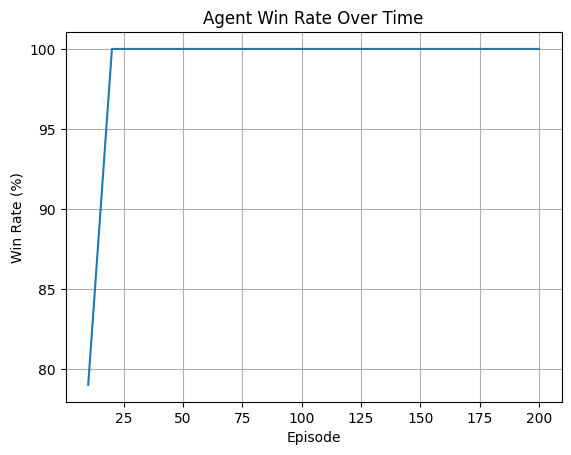

In [76]:
# Plotting the win rates over time

# The win rate measurement uses the greedy policy snapshot for 200 evaluation
# games


import matplotlib.pyplot as plt
plt.plot(episode_numbers, win_rates)
plt.xlabel('Episode')
plt.ylabel('Win Rate (%)')
plt.title('Agent Win Rate Over Time')
plt.grid()
plt.show()

Q: Run the training loop with random seed =1 vs. random seed = 5, and epsilon = 0.  What do you observe? How can it be explained?

`YOUR ANSWER HERE`

Q: What happens when you change epsilon to 0.1.  What do you observe? How can it be explained?

`YOUR ANSWER HERE`

### Formalizing What We Just Did: Markov Decision Process (MDP)

You have now trained a reinforcement learning agent from scratch. Before wrapping up, let's give a precise name to the mathematical framework that describes everything that happened.

Every element of the Nim game we worked with (the pile size, the allowed moves, the +1/−1 rewards, the transition from one game state to the next) fits into a single unified model called a **Markov Decision Process**, or **MDP**.

#### What Makes It "Markov"?

To decide what to do next, the agent only needs to know the **current state**. The full history of how it got there does not factor into the decision. In Nim, all that matters is *how many objects are left right now*. Whether the pile started at 6 and the agent took 2, or started at 5 and the opponent took 1, the situation is identical from state 3 onward. This "the past doesn't matter beyond the present state" property is called the **Markov property**.

#### The Four Components of an MDP

An MDP is a mathematical model for sequential decision-making. Formally, an MDP is the tuple $(S,\, A,\, P,\, R)$:

| Symbol | Name | What it captures | In our Nim game |
|---|---|---|---|
| $S$ | **State space** | All possible situations the agent can be in | $\{1, 2, 3, 4, 5, 6\}$ — the number of objects remaining |
| $A$ | **Action space** | All choices available to the agent | $\{1, 2\}$ — take 1 or take 2 objects |
| $P(s' \mid s, a)$ | **Transition probabilities** | How likely are we to move to state $s'$ after taking action $a$ in state $s$ | In our version, the agent's move is deterministic, but the opponent's random choice introduces probability |
| $R(s, a, s')$ | **Reward function** | The immediate numerical signal the agent receives for each transition | $+1$ for a win, $-1$ for a loss, $0$ for all intermediate steps |


#### Connecting the MDP to the Q-Learning Loop


The goal of Q-learning is to find the **optimal policy** $\pi^*$, the mapping from states to actions that maximizes expected cumulative reward, without ever being given the transition probabilities $P$ or the reward function $R$ explicitly. The agent discovers them purely through interaction.

#### Why MDPs Matter Beyond Nim

Nim is tiny: 6 states, 2 actions, a handful of games to converge. But the MDP framework scales to settings that are vastly more complex:

- **Game playing**: AlphaGo's state space is the Go board ($\approx 10^{170}$ positions); the actions are stone placements. The training used the same Q-learning principles, with a neural network approximating the Q-table.
- **Robotics**: A robot arm's state is its joint angles and velocities; actions are motor torques; rewards come from task completion. Physical simulation provides the transitions.
- **Recommendation systems**: The "state" is a user's viewing history; "actions" are which video to recommend next; the reward is whether the user watches it.

In all of these, the key question is the same: given a state, which action leads to the highest total expected reward over time?